--- Pemilih Metrik Lohong Hitam (Berdasarkan Framework Tesis) ---
1: Schwarzschild (Standard)
2: Reissner-Nordström (Bercas Q)
3: Kottler / S-deSitter (Pemalar Lambda)
4: Bardeen (Regular / Tanpa Singularity)
5: Schwarzschild-Anti-de Sitter (SAdS)
6: Hayward (Regular / Teras Quantum)
7: Kiselev (Quintessence Fluid)
8: Mannheim-Kazanas (Conformal Gravity)

Metrik yang dipilih ialah metrik Kiselev (Quintessence Fluid)

--- event horizon ---


Eq(event_horizon, 2.25403330758517)

event_{horizon} = 2.25403330758517


--- lapse function ---


Eq(lapse, -2*M/r - a*r**(-3*w - 1) + 1)

lapse = - \frac{2 M}{r} - a r^{- 3 w - 1} + 1


--- 1. LAGRANGIAN (L) ---


...

b = 6.89560699462891


--- 6. ORBITAL EQUATION (dr/dphi)^2 ---


Eq(dr_dphi_square, 2.0*M*r + 1.0*a*r/r**(3*w) - 1.0*r**2 + 1.0*r**4/b**2)

dr_{dphi square} = 2.0 M r + 1.0 a r r^{- 3 w} - 1.0 r^{2} + \frac{1.0 r^{4}}{b^{2}}


--- 7. ODE FOR SOLVER (dr/dphi) ---


Eq(dr_dphi, sqrt(2.0*M*r + 1.0*a*r/r**(3*w) - 1.0*r**2 + 1.0*r**4/b**2))

dr_{dphi} = \sqrt{2.0 M r + 1.0 a r r^{- 3 w} - 1.0 r^{2} + \frac{1.0 r^{4}}{b^{2}}}


Firing 1000 photons...
Rendering plot...


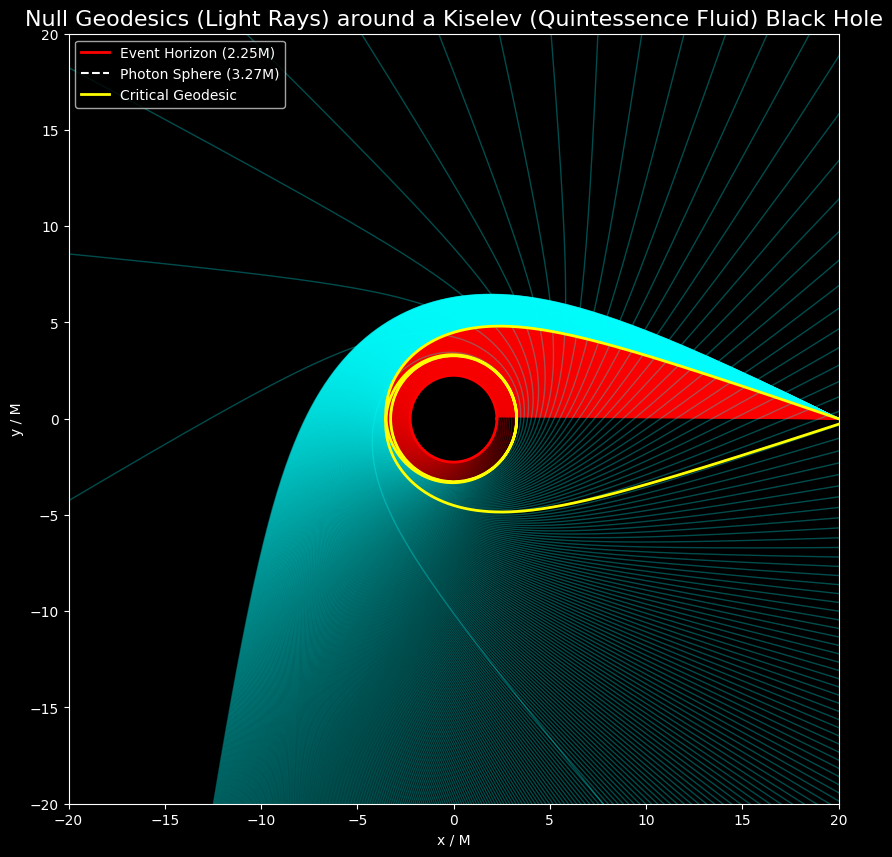

Rendered 640000 pixels.
Saved bh_shadow.png


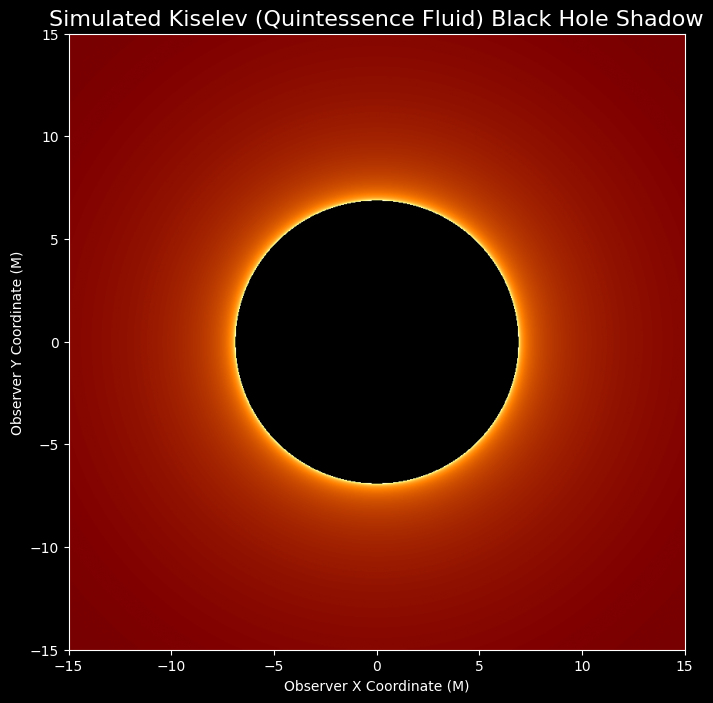

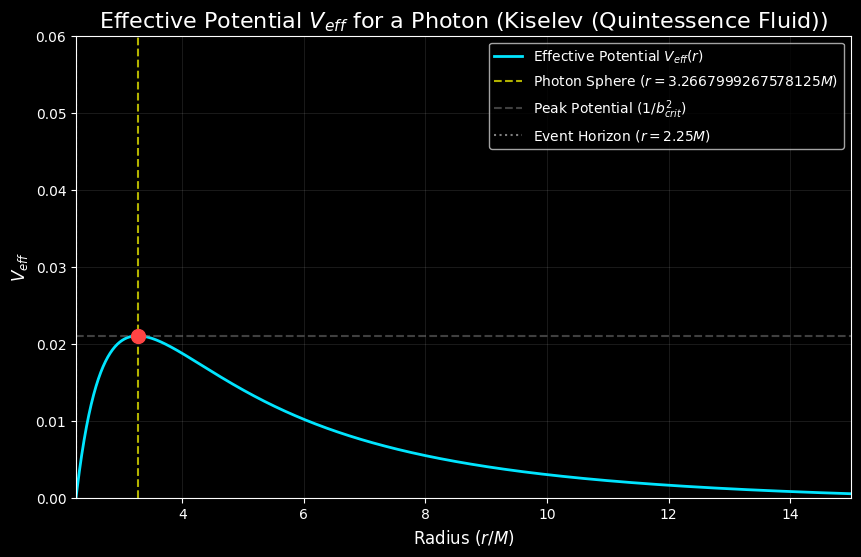

In [22]:
import sympy as sp
from sympy import *
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LightSource, Normalize
from matplotlib.colors import LinearSegmentedColormap

def automated_black_hole_engine():
    # 1. SETUP SYMBOLS (Unit natural G = c = 1)
    r, M, b = sp.symbols('r M b', positive=True, real=True)
    E, L = sp.symbols('E L', positive=True, real=True)
    A = sp.symbols('A') #for kottler (cosmological constant)
    b = sp.symbols('b')
    v = sp.symbols('v') 
    Q = sp.symbols('Q', positive=True, real=True) #for reissner-nordstrom (charge)
    g = sp.symbols('g') #for bardeen metric (the magnetic monopole charge)
    l = sp.symbols('l') #for hayward (the fundamental length scale)
    Ads = sp.symbols('Ads') #for sAds metric (the Ads curvature radius)
    a = sp.symbols('a') #for kiselev metric (quintessence density)
    w = sp.symbols('w') #for kiselev metric (equation of state)
    y = sp.symbols('y') #for mannheim-kazanas (the conformal parameter)
    k = sp.symbols('k') #for mannheim-kazanas (the conformal parameter)

    print("--- Pemilih Metrik Lohong Hitam (Berdasarkan Framework Tesis) ---")
    metrics = {
        "1": "Schwarzschild (Standard)",
        "2": "Reissner-Nordström (Bercas Q)",
        "3": "Kottler / S-deSitter (Pemalar Lambda)",
        "4": "Bardeen (Regular / Tanpa Singularity)",
        "5": "Schwarzschild-Anti-de Sitter (SAdS)",
        "6": "Hayward (Regular / Teras Quantum)",
        "7": "Kiselev (Quintessence Fluid)",
        "8": "Mannheim-Kazanas (Conformal Gravity)"
    }
    
    for key, name in metrics.items():
        print(f"{key}: {name}")
    
    choice = input("Pilih nombor metrik (1-8): ")
    print(f"\nMetrik yang dipilih ialah metrik {metrics.get(choice, 'Invalid Choice')}\n")
    # 2. DEFINISI F(R) BERDASARKAN DOKUMEN
    params = {M: 1.0}
    if choice == '1':
        f_r = 1 - 2*M/r
    elif choice == '2':
        f_r = 1 - 2*M/r + Q**2/r**2 # [cite: 21]
        params[Q] = 0.5
    elif choice == '3':
        f_r = 1 - 2*M/r - (A * r**2 / 3) # [cite: 31]
        params[A] = 0.01
    elif choice == '4':
        f_r = 1 - (2*M * r**2) / (r**2 + g**2)**(3/2) # [cite: 39]
        params[g] = 0.6
    elif choice == '5':
        f_r = 1 - 2*M/r + r**2/Ads**2 # [cite: 46]
        params[Ads] = 10.0
    elif choice == '6':
        f_r = 1 - (2*M * r**2) / (r**3 + 2*M*l**2) # [cite: 55]
        params[l] = 0.5
    elif choice == '7':
        f_r = 1 - 2*M/r - a/r**(3*w + 1) # [cite: 61]
        params[a] = 0.05
        params[w] = -2/3 # Quintessence case [cite: 63]
    elif choice == '8':
        f_r = 1 - 2*M/r + y*r - k*r**2 # [cite: 68]
        params[y] = 0.01
        params[k] = 0.001
    else:
        print("Pilihan tidak sah.")
        return
    M=1.0
    # =====================================================================
    # DYNAMIC HORIZON CALCULATOR
    # =====================================================================
    # We need to find the root where f(r) = 0
    f_r_numeric = f_r.subs(params)

    # Change this in your Dynamic Horizon Calculator:
    try:
        roots = sp.solve(f_r_numeric, r)
        real_roots = [float(sp.re(sol)) for sol in roots if sol.is_real or sol.is_Atom]
        
        # Instead of max(), pick the one closest to 2.0 (Schwarzschild)
        r_h_val = min(real_roots, key=lambda x: abs(x - 2.0)) 
    except:
        r_h_val = float(sp.nsolve(f_r_numeric, r, 2.0))

    event_horizon = sp.symbols('event_horizon')


    print("--- event horizon ---")
    display(Eq(event_horizon,r_h_val))
    print_latex(Eq(event_horizon,r_h_val))
    print("\n")

    # =====================================================================
    # 1. DEFINE SYMBOLIC VARIABLES
    # =====================================================================
    # We define our coordinates, parameters, and their derivatives (dots)
    t_dot, r_dot, phi_dot = sp.symbols('t_dot r_dot phi_dot', real=True)
    dr_dphi = sp.symbols('dr_dphi')
    lagrangian =sp.symbols('lagrangian')
    r_dot_square = sp.symbols('r_dot_square')
    dr_dphi_square = sp.symbols('dr_dphi_square')
    lapse = sp.symbols('lapse')

    print("--- lapse function ---")
    display(Eq(lapse,f_r))
    print_latex(Eq(lapse,f_r))
    print("\n")

    # =====================================================================
    # 2. DERIVE THE LAGRANGIAN 
    # =====================================================================
    # General metric form: ds^2 = -f(r)dt^2 + f(r)^(-1)dr^2 + r^2 d_phi^2
    # (Assuming equatorial plane where theta = pi/2, so theta_dot = 0)
    L_expr = 0.5 * (-f_r * t_dot**2 + (1/f_r) * r_dot**2 + r**2 * phi_dot**2)

    print("--- 1. LAGRANGIAN (L) ---")
    display(Eq(lagrangian,L_expr))
    print_latex(Eq(lagrangian,L_expr))
    print("\n")


    # =====================================================================
    # 3. DERIVE CONSTANTS OF MOTION (E and L)
    # =====================================================================
    # Find Time Momentum (Energy): p_t = dL/dt_dot = -E
    p_t = sp.diff(L_expr, t_dot)
    eq_E = sp.Eq(p_t, -E)
    # Solve for t_dot
    t_dot_sol = sp.solve(eq_E, t_dot)[0]

    # Find Angular Momentum: p_phi = dL/dphi_dot = L
    p_phi = sp.diff(L_expr, phi_dot)
    eq_L = sp.Eq(p_phi, L)
    # Solve for phi_dot
    phi_dot_sol = sp.solve(eq_L, phi_dot)[0]

    print("--- 2. CONSTANTS OF MOTION ---")
    display(Eq(t_dot,t_dot_sol))
    print_latex(Eq(t_dot,t_dot_sol))
    print("\n")
    display(Eq(phi_dot,phi_dot_sol))
    print_latex(Eq(phi_dot,phi_dot_sol))
    print("\n")


    # =====================================================================
    # 4. DERIVE RADIAL VELOCITY AND EFFECTIVE POTENTIAL
    # =====================================================================
    # Substitute t_dot and phi_dot back into the Lagrangian = 0
    L_subbed = L_expr.subs({t_dot: t_dot_sol, phi_dot: phi_dot_sol})

    # Isolate r_dot**2
    eq_r_dot = sp.Eq(L_subbed * 2, 0) # Multiply by 2 to clear the 1/2
    r_dot_squared_sol = sp.solve(eq_r_dot, r_dot**2)[0]

    print("--- 3. RADIAL VELOCITY (r_dot^2) ---")
    display(Eq(r_dot_square,r_dot_squared_sol))
    print_latex(Eq(r_dot_square,r_dot_squared_sol))
    print("\n")

    # For photon trajectories parameterized by impact parameter b, 
    # the effective potential is structurally defined as f(r) / r^2
    V_r = f_r / r**2

    print("--- 4. EFFECTIVE POTENTIAL V(r) ---")
    display(Eq(v,V_r))
    print_latex(Eq(v,V_r))
    print("\n")


    # =====================================================================
    # 5. FIND THE PHOTON SPHERE AND CRITICAL IMPACT PARAMETER
    # =====================================================================
    # Set dV/dr = 0 and solve for r
    dV_dr = sp.diff(V_r, r)
    display(dV_dr)
    try:
        # 1. ATTEMPT EXACT ANALYTICAL SOLUTION
        # This works perfectly for Schwarzschild, Reissner-Nordström, and Kottler
        r_ph_solutions = sp.solve(dV_dr, r)
        
        # If SymPy cannot find a solution, it returns an empty list []. 
        # We manually trigger an error here so it jumps to the numerical solver.
        if not r_ph_solutions:
            raise ValueError("No analytical solution found.")
            
        display(r_ph_solutions)
        
        # Get the valid root 
        # (For simple metrics, [0] is usually the correct positive root)
        # Ensure we only pick the positive real root that is outside the horizon
        r_ph_final = max([sol for sol in r_ph_solutions if sol.is_real and sol > r_h_val])
        
        # Calculate max potential and critical impact parameter symbolically
        V_max = V_r.subs(r, r_ph)
        b_crit = 1 / sp.sqrt(V_max)
        b_crit_final = sp.simplify(b_crit)
        
        print("\n[Status: Analytical Derivation Successful]")

    except Exception:
        # 2. NUMERICAL FALLBACK
        # If exact math fails (Bardeen, Hayward, Kiselev, etc.), switch to Numerical Solver
        print("\n[Status: Analytical derivation too complex. Switching to Numerical Solver...]")
        
        # Substitute our numerical parameters (M=1.0, g=0.6, etc.) into the equation FIRST
        dV_dr_numeric = dV_dr.subs(params)
        
        # sp.nsolve uses numerical approximation to find the root. We give it an initial guess of r=3.0
        r_ph_numeric = sp.nsolve(dV_dr_numeric, r, 3.0)
        
        # Convert to a SymPy Float (rounded to 5 decimal places) so it prints nicely in LaTeX
        r_ph = sp.Float(r_ph_numeric, 5) 
        
        # Calculate max potential and critical impact parameter numerically
        V_max_numeric = V_r.subs(r, r_ph_numeric).subs(params)
        b_critical_numeric = 1 / sp.sqrt(V_max_numeric)
        
        # Convert to a SymPy Float for nice LaTeX display
        b_critical = sp.Float(b_critical_numeric, 5)

        r_ph_final = r_ph * M
        b_crit_final = b_critical * M
    print("--- 5. OPTICAL BOUNDARIES ---")
    print(f"Photon Sphere radius (r_ph): {r_ph_final}") 
    display(Eq(r,r_ph_final))
    print_latex(Eq(r,r_ph_final))
    print("\n")
    print(f"Critical Impact Parameter (b_crit): {b_crit_final}") 
    display(Eq(b,b_crit_final))
    print_latex(Eq(b,b_crit_final))
    print("\n")


    # =====================================================================
    # 6. DERIVE THE ORBITAL EQUATION (dr/dphi)^2 AND dr/dphi
    # =====================================================================
    # Chain rule: (dr/dphi)^2 = (r_dot)^2 / (phi_dot)^2
    dr_dphi_squared = r_dot_squared_sol / (phi_dot_sol**2)

    # Substitute Energy with Impact Parameter: E**2 = (L/b)**2
    dr_dphi_squared_b = dr_dphi_squared.subs(E**2, (L/b)**2)

    # Simplify to get the final geometric shape equation
    dr_dphi_squared_final = sp.simplify(dr_dphi_squared_b)

    # Take the square root to get the actual 1st-order ODE for your solver
    dr_dphi_final = sp.sqrt(dr_dphi_squared_final)

    print("--- 6. ORBITAL EQUATION (dr/dphi)^2 ---")
    display(Eq(dr_dphi_square,dr_dphi_squared_final))
    print_latex(Eq(dr_dphi_square,dr_dphi_squared_final))
    print("\n")
    print("--- 7. ODE FOR SOLVER (dr/dphi) ---")
    display(Eq(dr_dphi,dr_dphi_final))
    print_latex(Eq(dr_dphi,dr_dphi_final))
    print("\n")


    #SIMULATION PART FOR PHOTON SPHERE
    # =====================================================================
    # 8. NUMERICAL SIMULATION
    # =====================================================================
    # --- Build a METRIC-SPECIFIC u'' function from the chosen f(r) ---
    # FIX #4: derive u_double_prime from the actual metric, not hardcoded Schwarzschild.
    # The null geodesic equation in terms of u = 1/r is:
    #   d²u/dφ² = -u + (1/2) d/du [ f(1/u) / u² ]  (derived from dV/dr = 0 condition generalised)
    # We compute this symbolically then lambdify.
    u_sym = sp.symbols('u', positive=True)
    f_u   = f_r.subs(r, 1/u_sym)           # f(r) → f(1/u)
    H_u   = f_u * u_sym**2                      # H(u) = f(1/u) · u²  (= 1/b² at turning point)
    dH_du = sp.diff(H_u, u_sym)
    rhs   = -sp.Rational(1, 2) * dH_du           # d²u/dφ² = (1/2) dH/du
    
    rhs_numeric = rhs.subs(params)              # substitute M, Q, g, etc.
    u_double_prime = sp.lambdify(u_sym, rhs_numeric, modules='numpy')
    f_u_func = sp.lambdify(u_sym, f_u.subs(params), modules='numpy')

    def runge_kutta_4_step(u, u_prime, d_phi, M):

        k1_u = u_prime
        k1_up = u_double_prime(u)

        k2_u = u_prime + 0.5 * d_phi * k1_up
        k2_up = u_double_prime(u + 0.5 * d_phi * k1_u)

        k3_u = u_prime + 0.5 * d_phi * k2_up
        k3_up = u_double_prime(u + 0.5 * d_phi * k2_u)

        k4_u = u_prime + d_phi * k3_up
        k4_up = u_double_prime(u + d_phi * k3_u)

        u_new = u + (d_phi / 6.0) * (k1_u + 2*k2_u + 2*k3_u + k4_u)
        u_prime_new = u_prime + (d_phi / 6.0) * (k1_up + 2*k2_up + 2*k3_up + k4_up)

        return u_new, u_prime_new

    def trace_photon(b, M=1.0, step_size=0.02, max_steps=7000):
        r_obs = 20.0 * M      
        
        if b == 0:
            return [r_obs, 0], [0, 0], "captured"

        # 1. Correct Starting Position
        # For a photon to have impact parameter 'b', its initial angle 
        # must account for the offset: sin(phi) = b / r
        if b >= r_obs: # Photon is starting outside the 'viewing' circle
            return [r_obs], [0], "escaped"
            
        initial_phi = np.arcsin(b / r_obs)
        u = 1.0 / r_obs
        
        # 2. Correct Initial Velocity (u')
        # Use the null geodesic energy equation: (u')^2 = 1/b^2 - f(u)u^2
        # We substitute the specific metric values at the start
        f_u_start = f_u_func(u)
        u_p_sq = (1.0 / b**2) - (f_u_start * u**2)
        
        if u_p_sq < 0:
            return [r_obs], [0], "escaped"
        
        # We use negative sqrt if we want the photon moving inward (u increasing)
        # but the solver will handle the direction based on the sign of u_prime.
        # To start from r_obs and move toward the BH, u must increase:
        u_prime = np.sqrt(u_p_sq) 
        
        x_vals, y_vals = [], []
        current_phi = initial_phi 

        for _ in range(max_steps):
            r_val = 1.0 / u if u > 0 else 1e10
            
            # Convert polar to Cartesian
            # We subtract initial_phi to align the incoming rays horizontally
            x = r_val * np.cos(current_phi - initial_phi)
            y = r_val * np.sin(current_phi - initial_phi)
            
            x_vals.append(x)
            y_vals.append(y)

            # Stop conditions
            if r_val <= r_h_val * 1.01: # Dynamic stop based on the actual metric: # Slightly outside EH for stability
                status = "captured"
                break
            if r_val > r_obs * 2.0:
                status = "escaped"
                break
            if u < 0: # Photon flying off to infinity
                status = "escaped"
                break

            u, u_prime = runge_kutta_4_step(u, u_prime, step_size, M)
            
            # As the photon moves "left" from the right side, 
            # phi increases in our polar integration
            current_phi += step_size 

        return x_vals, y_vals, status

    # ==========================================
    # SIMULATION & PLOTTING SETUP
    # ==========================================
   
    b_crit = float(b_crit_final.subs(params)) if b_crit_final.free_symbols else float(b_crit_final)

    # Generate 100 photons with impact parameters from 0.1 to 10
    # (We skip exact 0 to avoid overlapping lines in the visual center)
    impact_parameters = np.linspace(0.1, 10.0, 1000)

    plt.figure(figsize=(10, 10))
    plt.style.use('dark_background') # Makes it look like space!

    print("Firing 1000 photons...")

    for b in impact_parameters:
        x, y, status = trace_photon(b, M)
        
        # Color-code the trajectories based on their fate
        if status == "captured":
            plt.plot(x, y, color='red', alpha=0.3, linewidth=1)
        else:
            plt.plot(x, y, color='cyan', alpha=0.3, linewidth=1)

    # ==========================================
    # DRAW THE BLACK HOLE AND PHOTON SPHERE
    # ==========================================

    # Create circles for the Event Horizon and Photon Sphere
    theta = np.linspace(0, 2*np.pi, 200)
    r_ph_val   = float(r_ph_final.subs(params))   if r_ph_final.free_symbols   else float(r_ph_final)

    # Event Horizon (Black solid circle)
    eh_x = r_h_val * np.cos(theta)
    eh_y = r_h_val * np.sin(theta)
    plt.fill(eh_x, eh_y, color='black', zorder=5)
    plt.plot(eh_x, eh_y, color='red', linewidth=2, zorder=5, label=f'Event Horizon ({r_h_val:.2f}M)')

    # Photon Sphere (White dashed circle)
    ps_x = r_ph_val * np.cos(theta)
    ps_y = r_ph_val * np.sin(theta)
    plt.plot(ps_x, ps_y, color='white', linestyle='--', linewidth=1.5, zorder=4, label=f'Photon Sphere ({r_ph_val:.2f}M)')

    # Add this right before plt.show()
    x_c, y_c, _ = trace_photon(b_crit, M)
    plt.plot(x_c, y_c, color='yellow', linewidth=2, label='Critical Geodesic', zorder=10)

    # Formatting the plot
    plt.title(f'Null Geodesics (Light Rays) around a {metrics[choice]} Black Hole', fontsize=16)
    plt.xlabel('x / M')
    plt.ylabel('y / M')
    plt.xlim(-20, 20)
    plt.ylim(-20, 20)
    plt.grid(False)
    plt.legend(loc='upper left')
    plt.gca().set_aspect('equal', adjustable='box')

    print("Rendering plot...")
    plt.savefig('null_geodesics.png')
    plt.show()
    plt.close()

    #BLACKHOLE SHADOW SIMULATION
    # ==========================================
    # 1. SET UP THE CAMERA SENSOR
    # ==========================================
    b_crit = float(b_crit_final.subs(params)) if b_crit_final.free_symbols else float(b_crit_final)

    # Camera settings
    resolution = 800  # An 800x800 pixel image
    fov = 15.0        # Field of View (how wide the camera sees, from -15M to +15M)

    # Create the 2D grid of pixels (x and y coordinates on the screen)
    x = np.linspace(-fov, fov, resolution)
    y = np.linspace(-fov, fov, resolution)
    X, Y = np.meshgrid(x, y)

    # ==========================================
    # 2. CALCULATE IMPACT PARAMETERS
    # ==========================================
    # Calculate the impact parameter 'b' for every single pixel simultaneously
    B = np.sqrt(X**2 + Y**2)

    # ==========================================
    # 3. RENDER THE IMAGE
    # ==========================================
    # Create a blank canvas (array of zeros)
    image = np.zeros((resolution, resolution))

    # Condition 1: The Shadow (Captured photons)
    # If B < b_crit, the pixel stays 0 (black)
    shadow_mask = B < b_crit
    image[shadow_mask] = 0.0

    # Condition 2: The Background (Escaped photons)
    # If B >= b_crit, the photon escapes. Let's make the background glow 
    # so we can see the shadow. We'll add a simple "lensing halo" effect 
    # where light gets brighter the closer it is to the photon ring.
    escape_mask = B >= b_crit

    # A simple gradient formula to simulate gravitational lensing brightness
    # We add a tiny number (1e-5) to prevent dividing by zero at the exact boundary
    brightness = 1.0 / (B[escape_mask] - b_crit + 0.01)**0.2
    image[escape_mask] = brightness

    # ==========================================
    # 4. DISPLAY THE RESULT
    # ==========================================
    fig2 = plt.figure(figsize=(8, 8), facecolor='black')
    plt.imshow(image, cmap=plt.cm.afmhot, origin='lower', extent=[-fov, fov, -fov, fov])

    # Formatting
    plt.title(f'Simulated {metrics[choice]} Black Hole Shadow', color='white', fontsize=16)
    plt.xlabel('Observer X Coordinate (M)', color='white')
    plt.ylabel('Observer Y Coordinate (M)', color='white')
    plt.tick_params(colors='white')
    print(f"Rendered {resolution * resolution} pixels.")
    fig2.savefig('bh_shadow.png', bbox_inches='tight', facecolor='black')
    print("Saved bh_shadow.png")
    plt.show()
    plt.close(fig2)


    # EFFECTIVE POTENTIAL VS RADIUS GRAPH
    # Set up parameters
    r_ph_val   = float(r_ph_final.subs(params))   if r_ph_final.free_symbols   else float(r_ph_final)

    f_r_lambdified = sp.lambdify(r, f_r.subs(params), modules='numpy')

    r_arr = np.linspace(2.01 * M, 15.0 * M, 1000)
    V_arr = f_r_lambdified(r_arr) / r_arr**2

    V_peak = float(V_r.subs(r, r_ph_val).subs(params))


    # Plotting
    plt.figure(figsize=(10, 6))
    plt.style.use('dark_background')

    plt.plot(r_arr, V_arr, color='#00e5ff', linewidth=2, label='Effective Potential $V_{eff}(r)$')

    # Mark the Photon Sphere
    plt.scatter([r_ph_val], [V_peak], color='#ff4444', s=100, zorder=5)
    plt.axvline(r_ph_val, color='yellow', linestyle='--', alpha=0.7, label=f'Photon Sphere ($r = {r_ph_val}M$)')
    plt.axhline(V_peak, color='gray', linestyle='--', alpha=0.5, label=f'Peak Potential ($1/b_{{crit}}^2$)')

    # Mark the Event Horizon
    plt.axvline(r_h_val, color='white', linestyle=':', alpha=0.5, label=f'Event Horizon ($r = {r_h_val:.2f}M$)')

    # Formatting
    plt.title(f'Effective Potential $V_{{eff}}$ for a Photon ({metrics[choice]})', fontsize=16)
    plt.xlabel('Radius ($r/M$)', fontsize=12)
    plt.ylabel('$V_{eff}$', fontsize=12)
    plt.xlim(r_h_val, 15.0)
    plt.ylim(0, 0.06)
    plt.legend(loc='upper right')
    plt.grid(alpha=0.1)
    plt.savefig('veff_plot.png', bbox_inches='tight')
    plt.show()
    plt.close()
automated_black_hole_engine()